In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Problem two


class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
###Q3
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [ ]:
###Q4
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
##Q5

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        for action, (rowd, col_d) in MOVES.items():
            new_row = row + rowd
            new_col = col + col_d
            new_state = (new_row, new_col)

            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)
        return legal_actions
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        rowd, col_d = MOVES[action]
        return (row + rowd, col + col_d)
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1


In [ ]:
###Test Grid

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [ ]:
###Problem 6


sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

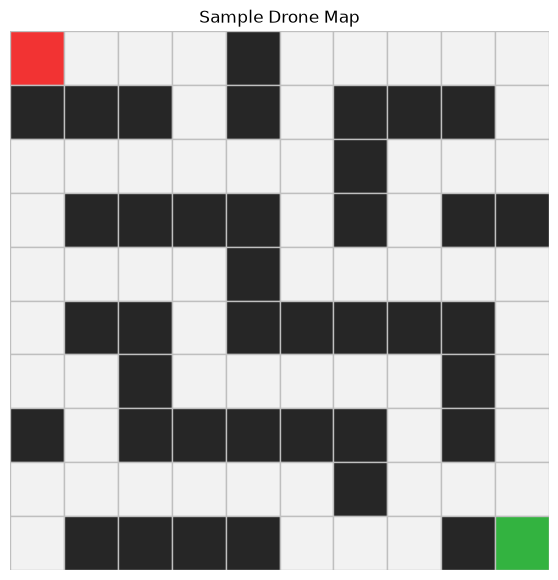

In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:

        s = node.state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        node = Node(problem.initial_state())

        nodes_expanded = 0
        max_frontier_size = 1

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="Sucess",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )
        frontier = deque([node])
        reached = {problem.initial_state()}

        ##Futher Expansion

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="Success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )


In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 1

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                solution=node,
                status="Success",
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        frontier = [node]

        reached = {problem.initial_state()}

        while frontier:
            node = frontier.pop()

            nodes_expanded += 1

            children = list(self.expand(problem, node))

            for child in reversed(children):
                s = child.state

                if s not in reached:
                    reached.add(s)

                    if problem.is_goal(s):
                        return SearchResult(
                            algorithm=algorithm,
                            status="Succes",
                            solution=child,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size=max_frontier_size,
                            reached_count=len(reached),
                        )
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
            algorithm=algorithm,
            status="Failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [ ]:
##Problem 11


class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        if problem.is_goal(node.state):
            return node, "Success"
        if node.depth >= limit:
            return node, "cutoff"

        metrics["nodes_expanded"] += 1
        cutOff_occured = False

        for child in self.expand(problem, node):
            curr_node = node
            cycle = False

            while curr_node is not None:
                if curr_node.state == child.state:
                    cycle = True

                if cycle:
                    continue

                # Update stack size

                metrics["metrics_stack_size"] = max(
                    metrics["max_stack_size"], current_stack_size + 1
                )

                result_node, result_status = self._recursive_dls(
                    problem, child, limit, metrics, current_stack_size + 1
                )

                if result_status == "Success":
                    return result_node, "Success"

                if result_status == "cutoff":
                    cutOff_occured = True

                if cutOff_occured:
                    return None, "cutoff"
                else:
                    return None, "Failure"

In [ ]:
##


class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        iteration_log = []
        dls = DepthLimitedSearch()

        nodes_expanded_total = 0
        max_frontier_size = 0
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            ##storing  results and status
            iteration_log.append(
                {
                    "limit": limit,
                    "status": result.status,
                    "nodes_expanded": result.nodes_expanded,
                    "max_frontier_size": result.max_frontier_size,
                }
            )

            nodes_expanded_total += result.nodes_expanded
            max_frontier_size = max(max_frontier_size, result.max_frontier_size)

            ##When there is success
            if result.status == "Success":
                return SearchResult(
                    algorithm=algorithm,
                    status="Success",
                    solution=result.solution,
                    nodes_expanded=nodes_expanded_total,
                    max_frontier_size=max_frontier_size,
                    limit=limit,
                    reached_count=result.reached_count,
                    iteration_log=iteration_log,
                )

            ##when there is Failure
            elif result.status == "Failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="Failure",
                    solution=None,
                    nodes_expanded=nodes_expanded_total,
                    max_frontier_size=max_frontier_size,
                    limit=limit,
                    reached_count=result.reached_count,
                    iterations=iteration_log,
                )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded_total,
            max_frontier_size=max_frontier_size,
            limit=max_depth,
            reached_count=0,
            iterations=iteration_log,
        )

        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

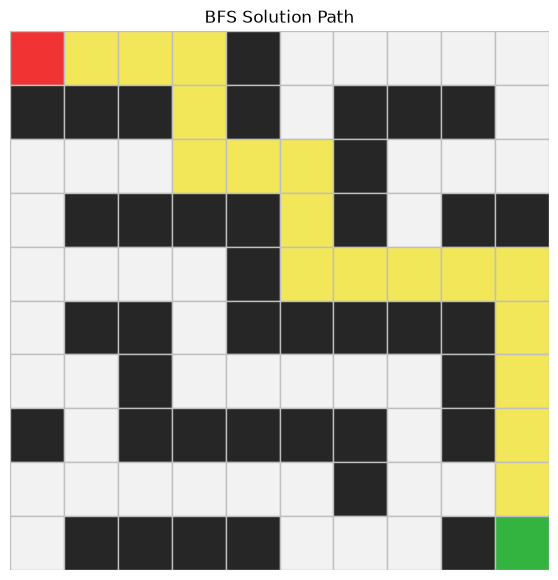

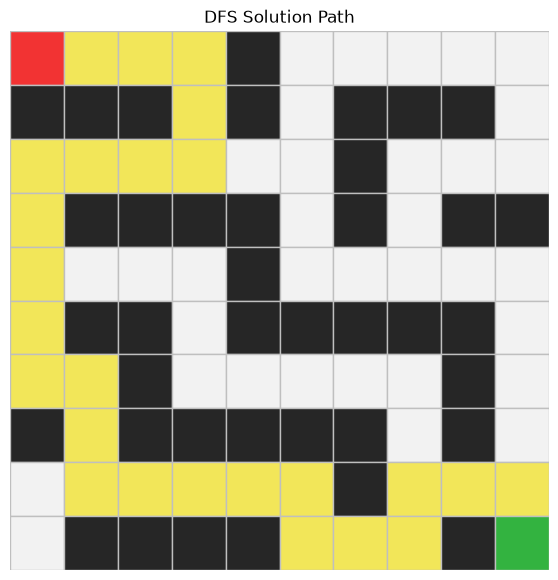

In [ ]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)


# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [ ]:
custom_grid_1 = [
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1, 0, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 0, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

In [ ]:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=30),
    ids.search(custom_problem_1, max_depth=50),
]

show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Sucess,NaN,18.0,18.0,22,3,24
1,DFS,Succes,NaN,18.0,18.0,18,3,21
2,DLS,cutoff,30.0,NaN,NaN,30,1,0
3,IDS,cutoff,50.0,NaN,NaN,1275,1,0


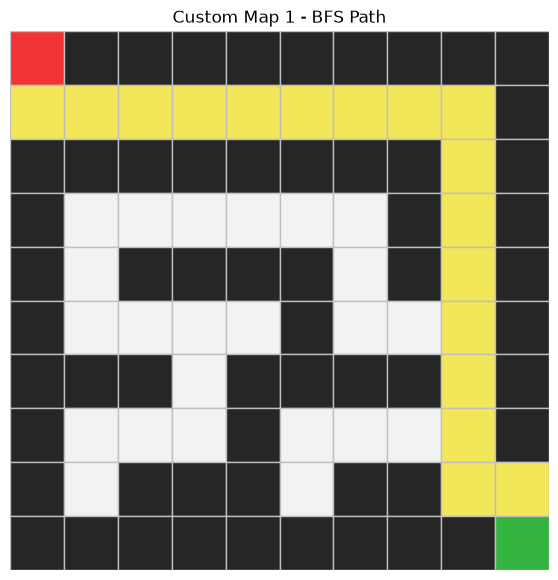

In [ ]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom Map 1 - BFS Path",
)

In [ ]:
custom_grid_2 = [
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)

In [ ]:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=25),
    ids.search(custom_problem_2, max_depth=50),
]

show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,Sucess,NaN,18.0,18.0,45,7,51
1,DFS,Succes,NaN,26.0,26.0,26,4,30
2,DLS,cutoff,25.0,NaN,NaN,25,1,0
3,IDS,cutoff,50.0,NaN,NaN,1275,1,0


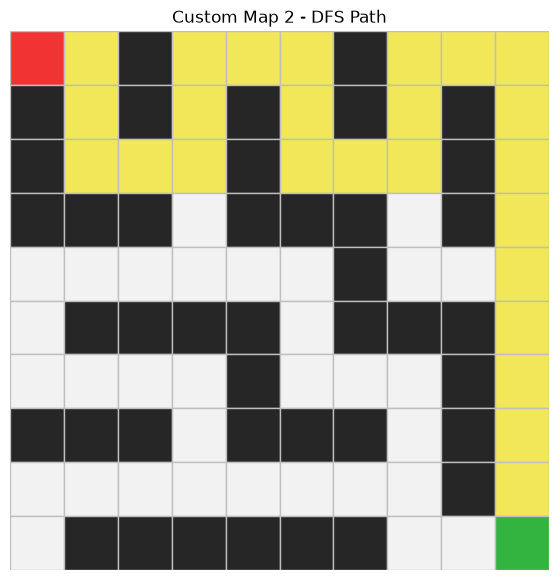

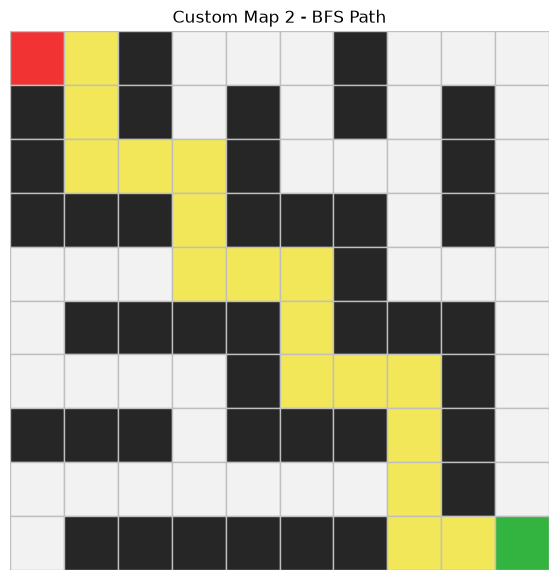

In [ ]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="Custom Map 2 - DFS Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="Custom Map 2 - BFS Path",
)

15.1 Problem Formulation

A state representa current position of the drone in the grid eg. a tuple like (row, col)

An action is a movement direction the drone can take:
This can be either:
UP, DOWN, LEFT, RIGHT.

The result (state, action):
it takes an action
it returns the new state after applying action
eg. (2,3) + RIGHT -> (2,4)

Seperating problem definition ffrom search algorithm allows :
Resuability
Modularity
Cleaner design

15.2

1.The BFS uses a FIFO Queue because it explores level by level and considers the earliest nodes first 2. The BFS finds the shortest path bacuse all moves have equal cost
the algorithm explores nodes in increasing depth order

3.  The reached set prevents: revisiting states
    the reached set avoids infinite loops
    it reduces redundancy
    it improves efficiency

    15.3
    1.  The DFS explores one path deeply before backtracking
        the DFS has a stack support which uses the LIFO behaviour
    2.  the dfs will use less memory when the branching factor is large
        its solution is deep
        the BFS frontier becomes huge
    3.  the dfs will perfom badly when it undergoes an ifinite or very deep search
        when it has many dead ends
        probably a cycle is not detected
        poor action order

    15.4
    1. if dls is small:
       the goal cannot be reached
       algortihm returns "cutoff"
    2. the cutoff used means a solution may exist but it has gone beyoud the depth limit for instance the max_depth = 3 but it explores to 4.

4.  the dfs has not depth limit
    the dls restricts search depth
    dls prevents ininite descent
5.  the path-cycle was checking to prevent :
    revisiting states on the current path
    infinite loops incycle graphs
    redundant exploration

    15.5 1.  
     small depth limits may miss soution
    increasing limit guarantees eventual recovery

         2
            the ids will eventually search all depths it increases limit step by step until solution depth is reached


         3.
            the ids behaves like dfs at each iteration
            it is stack-based


         4.
            the cost of repeatefd searchg from root involves:
                repeated expansions of shallow nodes
                higher time complexity than bfs
                extra computational overhead

    15.6
    1.  what makes a drone route safer or more parcrical:
        avoiding obstacles
        energy efficiency
        wind conditions
        diatance and flight time
        noticing restricted or no-flight zones
        the limitations of it battery or dry cell

    2.  In our quest for the fewest moves, the bfs is mos suitable because it guarantees the shortest path in steps and explores step by step

    3.  to limit search depth will require dls because it enforces maximum depth bounds.

    4.  the gid model ignores 3D space
        it assumes uniform movement cost
        the obstacles are simplified
        the hazards involved are not dynamic
        energy or battery constraints unavailable
